In [1]:
#Dataset=https://www.kaggle.com/c/dog-breed-identification/data
#Evaluation criteria-MultiClass log loss

In [2]:
#!unzip '/content/drive/MyDrive/Colab Notebooks/DogBreed/dog-breed-identification.zip' -d 'drive/MyDrive/Colab Notebooks/DogBreed/'

In [3]:
import tensorflow as tf
import tensorflow_hub as hub
print('GPU' if tf.config.list_physical_devices('GPU') else 'CPU') #Change in runtime

GPU


# New Section

In [4]:
import pandas as pd
labels_csv=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DogBreed/labels.csv')
labels_csv.describe()

,id,breed
count,10222,10222
unique,10222,120
top,fff43b07992508bc822f33d8ffd902ae,scottish_deerhound
freq,1,126


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


<Axes: xlabel='breed', ylabel='count'>

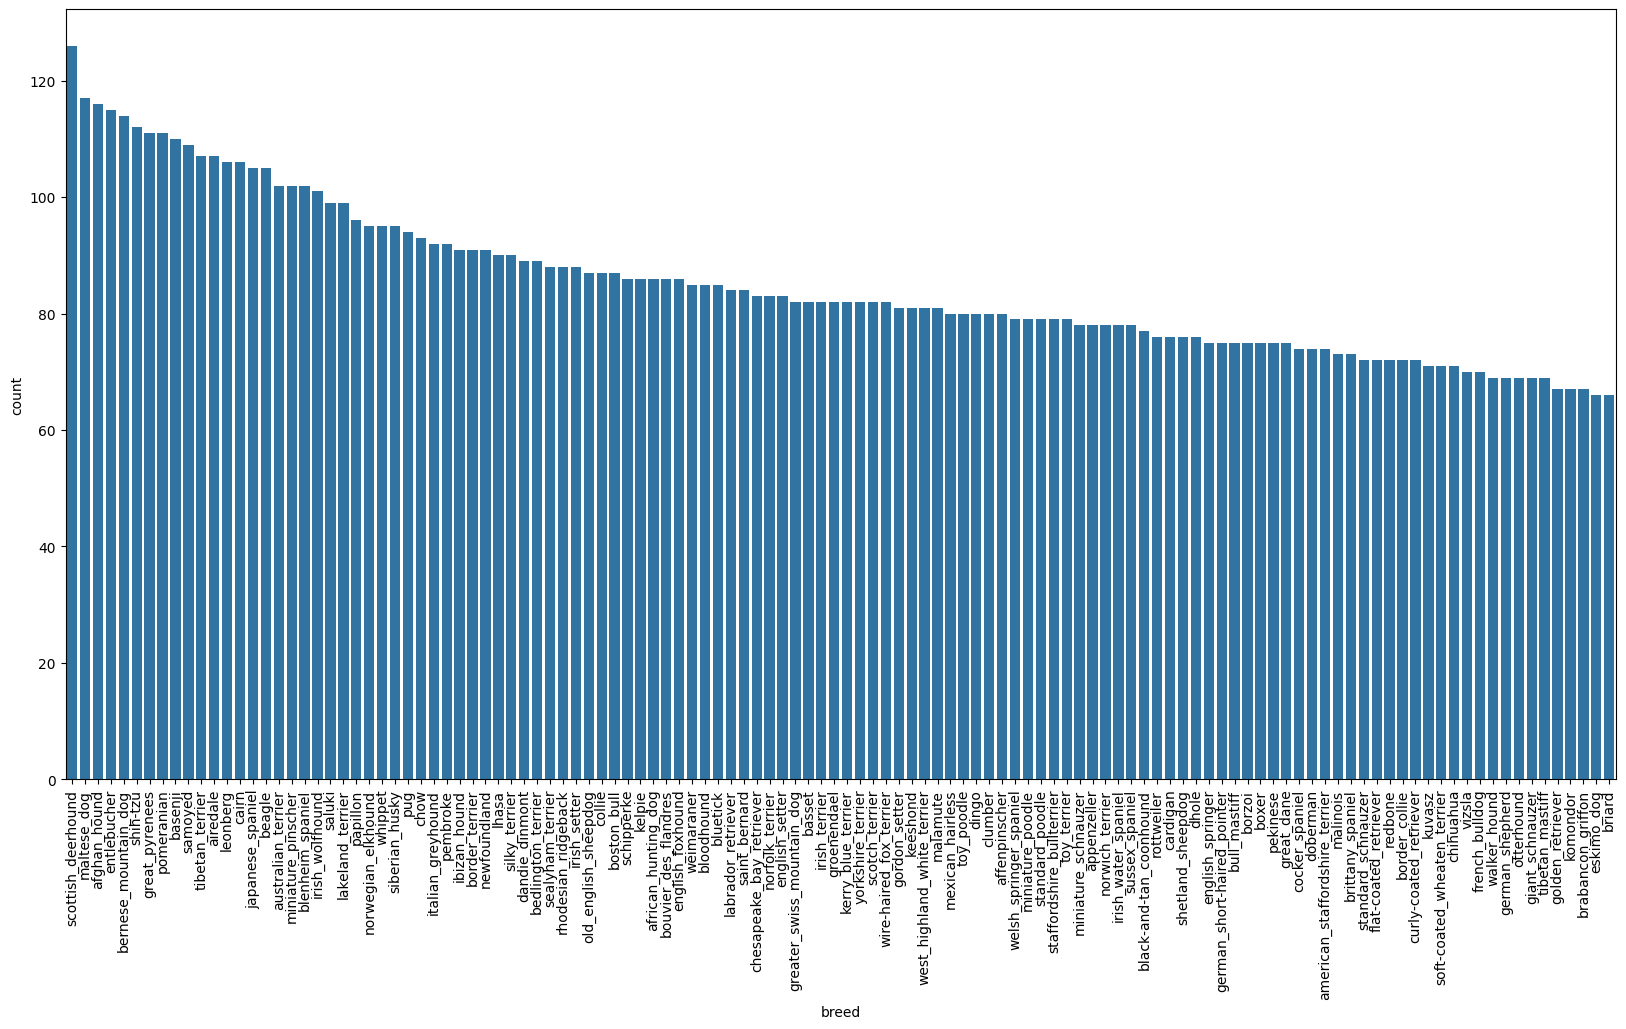

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plt.xticks(rotation=90)
sns.barplot(labels_csv['breed'].value_counts())

In [8]:
labels_csv['breed'].value_counts().median()

82.0

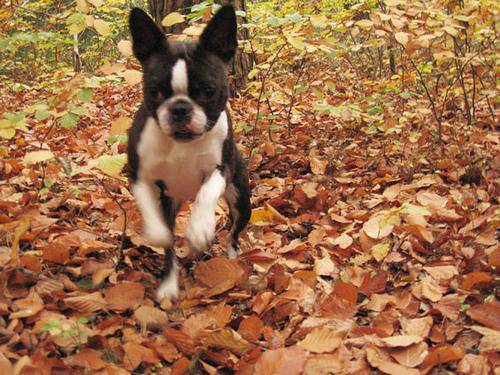

In [9]:
from IPython.display import Image
Image('/content/drive/MyDrive/Colab Notebooks/DogBreed/train/000bec180eb18c7604dcecc8fe0dba07.jpg')

In [10]:
#Create list of pathnames for images
filenames=[f"/content/drive/MyDrive/Colab Notebooks/DogBreed/train/"+fname+'.jpg' for fname in labels_csv['id']]
filenames[:5]

['/content/drive/MyDrive/Colab Notebooks/DogBreed/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/train/0021f9ceb3235effd7fcde7f7538ed62.jpg']

In [11]:
#Check no. of filenames match number of image files
import os
if len(os.listdir('/content/drive/MyDrive/Colab Notebooks/DogBreed/train'))==len(filenames):
  print('No. of files Match')
else:
  print('Filenames do not match no. of files')

No. of files Match


In [12]:
import numpy as np
labels=labels_csv['breed']
labels=np.array(labels)
labels[:5]

array(['boston_bull', 'dingo', 'pekinese', 'bluetick', 'golden_retriever'],
      dtype=object)

In [13]:
unique_breeds=np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [14]:
#Turn labels to boolean array
boolean_labels=[label==np.array(unique_breeds) for label in labels]
boolean_labels[:5]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [15]:
#Turn boolean array to int T-1 and F-0
int_labels=np.array(boolean_labels,dtype='int')
int_labels[:5]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0,

In [16]:
#Create own validation set
X=filenames
y=boolean_labels

In [17]:
#initially use less no. of images
num_images=1000


In [18]:

from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(X[:num_images],y[:num_images],test_size=0.2,random_state=42)


In [19]:
from matplotlib.pyplot import imread
image=imread(filenames[0])
image.shape

(375, 500, 3)

In [20]:
image[:2]

array([[[108,  46,   0],
        [152,  92,  42],
        [180, 120,  70],
        ...,
        [176, 144,  69],
        [189, 157,  82],
        [214, 182, 107]],

       [[151,  93,  47],
        [179, 121,  75],
        [167, 111,  64],
        ...,
        [167, 136,  56],
        [172, 139,  60],
        [188, 157,  77]]], dtype=uint8)

In [21]:
tf.constant(image)[:2]  #Convert image numpy array to tensor

<tf.Tensor: shape=(2, 500, 3), dtype=uint8, numpy=
array([[[108,  46,   0],
        [152,  92,  42],
        [180, 120,  70],
        ...,
        [176, 144,  69],
        [189, 157,  82],
        [214, 182, 107]],

       [[151,  93,  47],
        [179, 121,  75],
        [167, 111,  64],
        ...,
        [167, 136,  56],
        [172, 139,  60],
        [188, 157,  77]]], dtype=uint8)>

In [22]:
IMG_SIZE = 224

def process_image(image_path, img_size=IMG_SIZE):

  #read image file
  image = tf.io.read_file(image_path)
  #turn jpeg image into numerical Tensor
  image = tf.image.decode_jpeg(image, channels=3)
  #convert color channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)

  image = tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])

  return image

In [23]:
def get_image_label(image_path, label):
  image = process_image(image_path)
  return image, label

In [24]:
BATCH_SIZE = 32

def create_data_batches(X, y=None, batch_size=BATCH_SIZE, test_data=False):
  if test_data:
    print('creating TEST data batches')
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X)))    # only filepaths (no labels since test dataset)
    data_batch = data.map(process_image).batch(BATCH_SIZE)  #map function used instead of looping,reference of function is passed as map feedss the value to the function dynamically
    return data_batch

  else:
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),  # filepaths
                                               tf.constant(y)))  # labels
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch



In [25]:
train_data=create_data_batches(X_train,y_train)
val_data=create_data_batches(X_val,y_val)

In [26]:
#Visualizing

In [27]:
def show_5_images(images, labels):

    plt.figure(figsize=(10,10))
    for i in range(5):
        ax = plt.subplot(3, 2, i+1)
        plt.imshow(images[i])
        plt.title(unique_breeds[labels[i].argmax()])
        plt.axis('off')

32 32


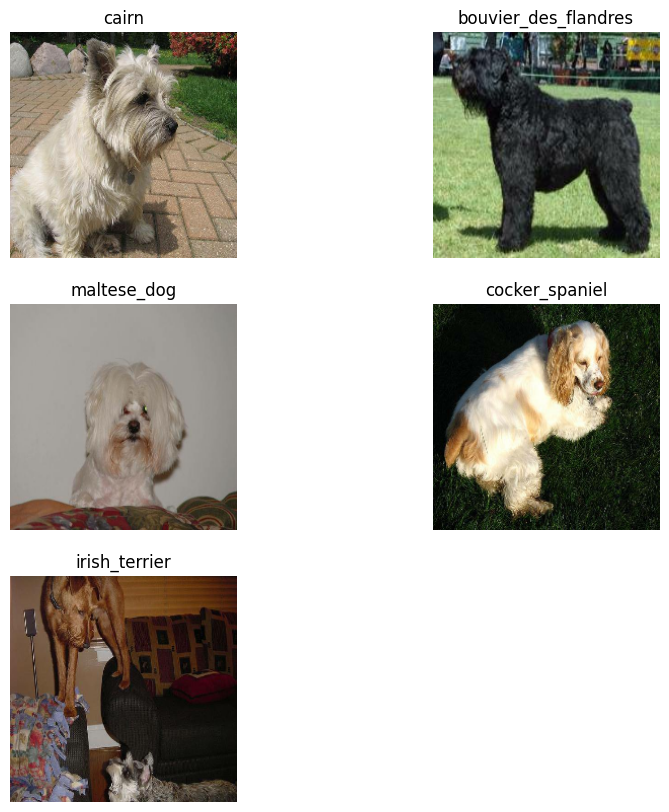

In [28]:
train_images,train_labels=next(train_data.as_numpy_iterator())  #returns first batch of training data as numpy array
print(len(train_images),len(train_labels))
show_5_images(train_images,train_labels)

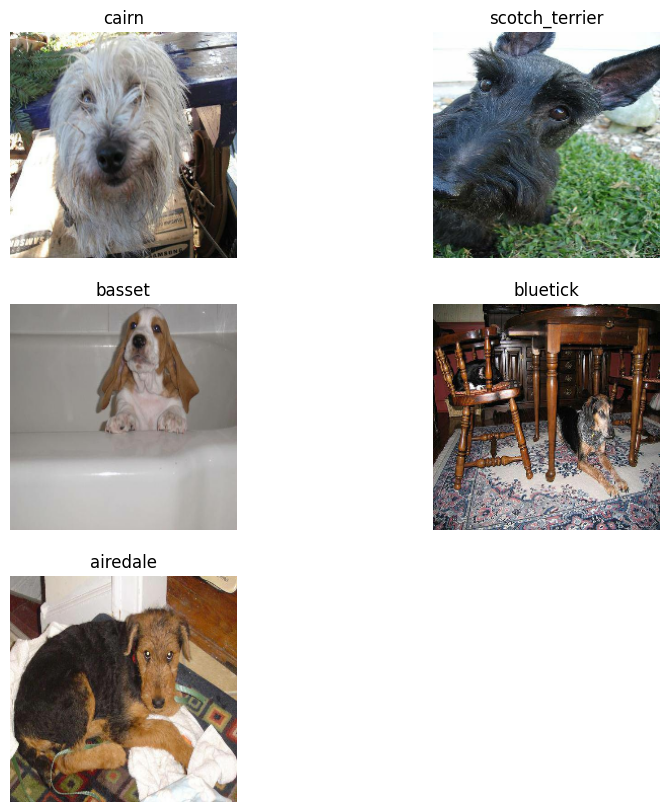

In [29]:
val_images, val_labels = next(val_data.as_numpy_iterator()) #validation data
show_5_images(val_images, val_labels)

In [30]:
#model
from tensorflow.keras.applications import MobileNetV2
print(train_data.element_spec)
print(val_data.element_spec)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)   # batch, height, width, color channels

# Setup output shape of our model
OUTPUT_SHAPE = len(unique_breeds)

#MODEL_URL='https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet1k_b0/classification/2'
MODEL = MobileNetV2(input_shape=INPUT_SHAPE,include_top=False,weights='imagenet')
MODEL.trainable = False #set training of v2model to flse(only train your own layers)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))


In [31]:
from tensorflow.keras import layers,Model
def create_model():
    print("Building model...")

    # Define input
    inputs = tf.keras.Input(shape=INPUT_SHAPE)

    # Pass inputs through MobileNetV2
    x = MODEL(inputs)  # MODEL is MobileNetV2(include_top=False, weights='imagenet')

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense output layer
    outputs = layers.Dense(OUTPUT_SHAPE, activation="softmax")(x)

    # Build functional model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [32]:
model = create_model()
model.summary()

Building model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,411,704 (9.20 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                    patience=5) #stop if val accuracy doesnt increase for 5 epochs


In [34]:
def train_model():

    model = create_model()

    model.fit(x=train_data,
            epochs=100,
            validation_data=val_data,
            callbacks=[early_stopping]
            )

    # return the fitted model
    return model


In [35]:
model = train_model()

Building model...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.0315 - loss: 4.9172 - val_accuracy: 0.2300 - val_loss: 3.5100
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.7235 - loss: 1.9700 - val_accuracy: 0.4950 - val_loss: 2.3744
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.9405 - loss: 0.8257 - val_accuracy: 0.6050 - val_loss: 1.9180
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9771 - loss: 0.4294 - val_accuracy: 0.6400 - val_loss: 1.7301
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9941 - loss: 0.2676 - val_accuracy: 0.6400 - val_loss: 1.6410
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - accuracy: 0.9990 - loss: 0.1873 - val_accuracy: 0.6500 - val_loss: 1.5885
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.9990 - loss: 0.1404 - val_accuracy: 0.6500 - val_loss: 1.5534
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 1.0000 - loss:

In [36]:
#make predictions on val data
predictions=model.predict(val_data,verbose=1)
predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 869ms/step


array([[8.13738967e-04, 2.11946876e-03, 8.31122597e-05, ...,
        6.95204872e-05, 2.70295655e-04, 2.18587229e-03],
       [5.56267260e-05, 3.22496402e-04, 8.14072671e-04, ...,
        2.23776788e-05, 1.73679274e-03, 2.41088837e-05],
       [7.04172862e-06, 3.37690464e-04, 3.38350947e-04, ...,
        3.28578390e-05, 9.16630888e-05, 8.24119721e-04],
       ...,
       [2.14565196e-04, 3.76626791e-04, 2.38787004e-04, ...,
        9.78364333e-05, 4.46698868e-05, 1.87317244e-04],
       [6.67143555e-04, 1.01294652e-04, 1.90591192e-04, ...,
        2.33278279e-05, 8.89668954e-05, 6.76249573e-03],
       [1.02807695e-04, 5.93533105e-06, 1.36868097e-04, ...,
        6.77516800e-04, 5.75461425e-04, 3.55620665e-04]], dtype=float32)

In [37]:
print(predictions.shape)
print(len(y_val))
print(len(predictions[0]))
print(np.max(predictions[4]))   #confidence
print(unique_breeds[np.argmax(predictions[4])]) #predicted label of dog in validation data

(200, 120)
200
120
0.78095317
airedale


In [38]:
def get_pred_label(prediction_probabilities):
    return unique_breeds[np.argmax(prediction_probabilities)]  #returns predicted breed

pred_label = get_pred_label(predictions[0])
pred_label


'lhasa'

In [39]:
#unbatch validation dataset to make prediction on validation images
def unbatchify(data):   #turns (image,labels) tensor batch data to numpy arrays
    images = []
    labels = []
    for image, label in data.unbatch().as_numpy_iterator():
        images.append(image)
        labels.append(unique_breeds[np.argmax(label)])
    return images, labels

val_images, val_labels = unbatchify(val_data)
val_images[0], val_labels[0]

(array([[[0.29599646, 0.43284872, 0.3056691 ],
         [0.26635826, 0.32996926, 0.22846507],
         [0.31428418, 0.27701408, 0.22934894],
         ...,
         [0.77614343, 0.82320225, 0.8101595 ],
         [0.81291157, 0.8285351 , 0.8406944 ],
         [0.8209297 , 0.8263737 , 0.8423668 ]],
 
        [[0.2344871 , 0.31603682, 0.19543913],
         [0.3414841 , 0.36560842, 0.27241898],
         [0.45016077, 0.40117094, 0.33964607],
         ...,
         [0.7663987 , 0.8134138 , 0.81350833],
         [0.7304248 , 0.75012016, 0.76590735],
         [0.74518913, 0.76002574, 0.7830809 ]],
 
        [[0.30157745, 0.3082587 , 0.21018331],
         [0.2905954 , 0.27066195, 0.18401104],
         [0.4138316 , 0.36170745, 0.2964005 ],
         ...,
         [0.79871625, 0.8418535 , 0.8606443 ],
         [0.7957738 , 0.82859945, 0.8605655 ],
         [0.75181633, 0.77904975, 0.8155256 ]],
 
        ...,
 
        [[0.9746779 , 0.9878955 , 0.9342279 ],
         [0.99153054, 0.99772066, 0.94278

In [40]:

def plot_pred(prediction_probabilities, labels, images,n):

    pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]

    # get predicted label
    pred_label = get_pred_label(pred_prob)

    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])

    # change color of title if pred is wrong
    if pred_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.title("{} {:2.0f}% ({})".format(pred_label,
                                        np.max(pred_prob)*100,
                                        true_label),
              color=color)


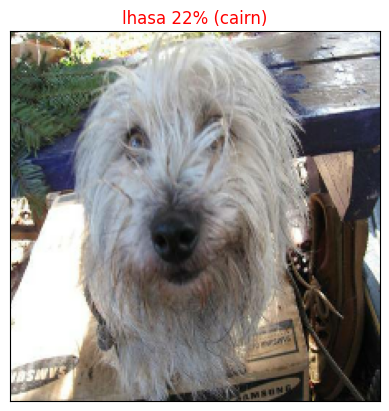

In [41]:
plot_pred(prediction_probabilities=predictions,
          labels=val_labels,
          images=val_images,
          n=0)

In [42]:
def plot_pred_conf(prediction_probabilities, n, labels=None): #plot top 10 predicted values

    import matplotlib.pyplot as plt
    import numpy as np

    pred_prob = prediction_probabilities[n]
    top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]
    top_10_pred_values = pred_prob[top_10_pred_indexes]
    top_10_pred_labels = unique_breeds[top_10_pred_indexes]

    # Plot bar chart
    plt.figure(figsize=(8, 5))
    bars = plt.bar(np.arange(len(top_10_pred_labels)),
                   top_10_pred_values,
                   color='slategray')
    plt.xticks(np.arange(len(top_10_pred_labels)),
               labels=top_10_pred_labels,
               rotation=45,
               ha='right')
    plt.ylabel("Confidence")
    plt.title("Top 10 Predicted Classes")
    plt.tight_layout()

    # Highlight true label if available
    if labels is not None:
        true_label = labels[n]
        if true_label in top_10_pred_labels:
            match_index = np.where(top_10_pred_labels == true_label)[0][0]
            bars[match_index].set_color('green')

    plt.show()

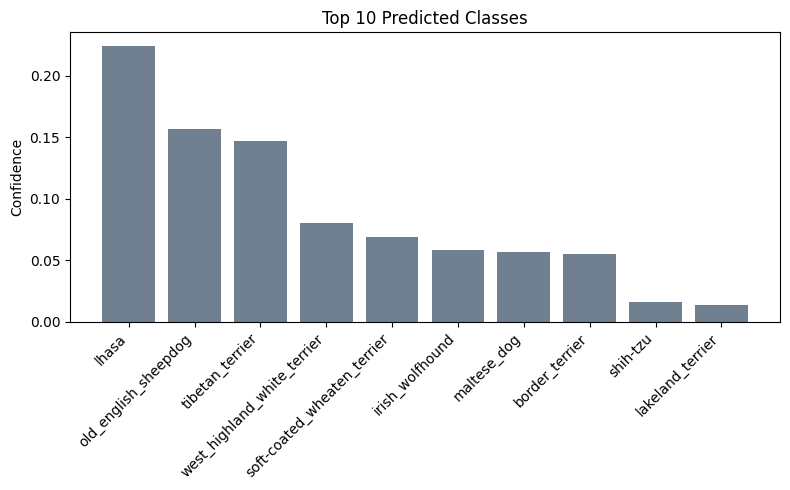

In [43]:
plot_pred_conf(prediction_probabilities=predictions,
               n=0,
               labels=val_labels,
               )

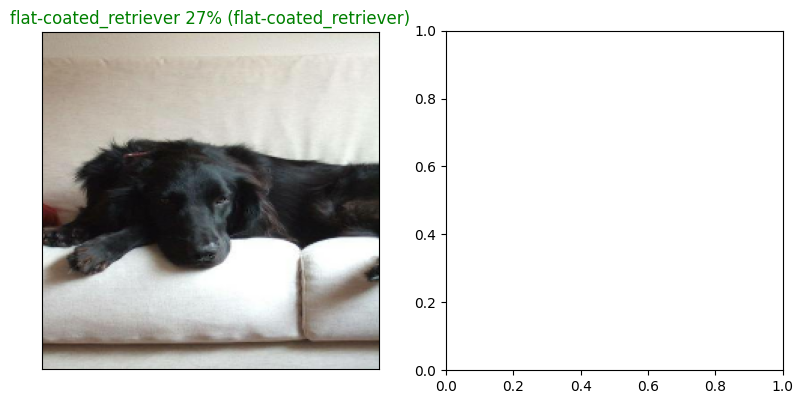

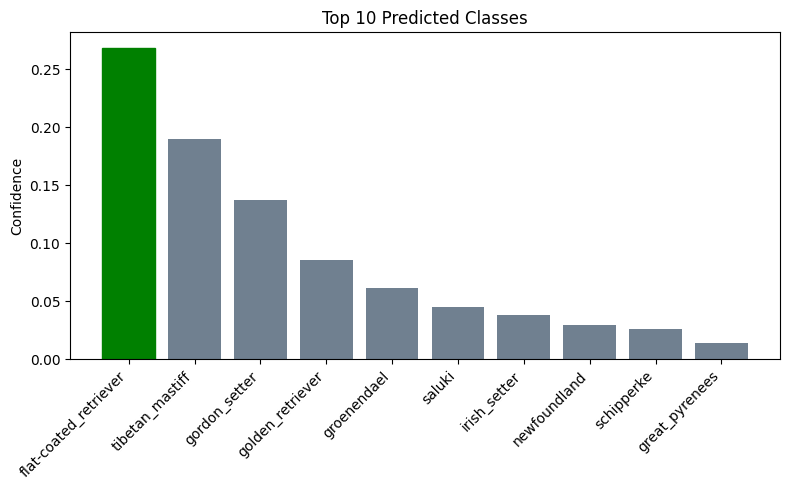

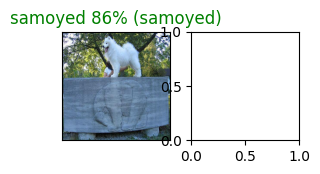

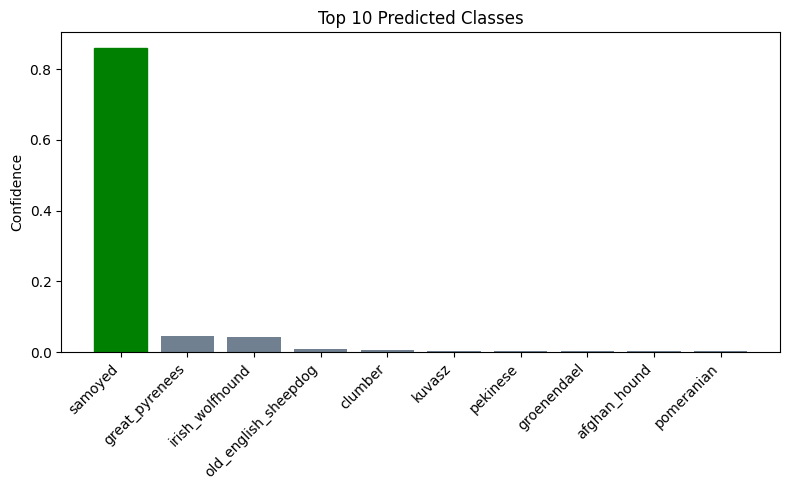

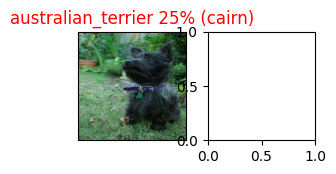

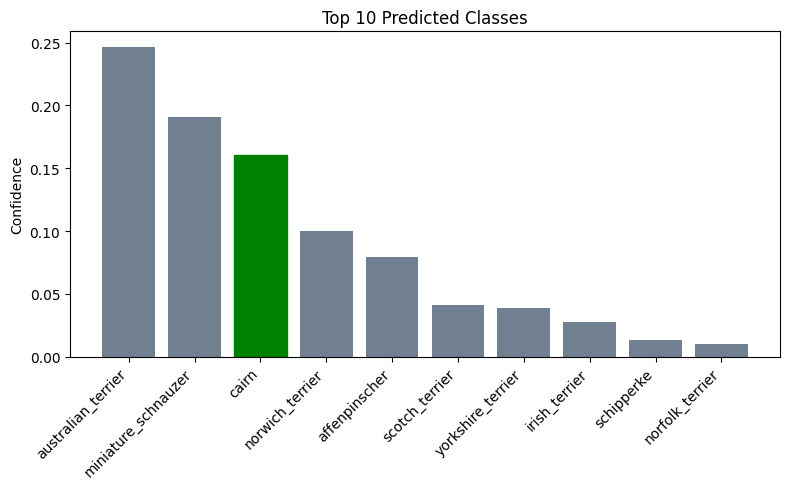

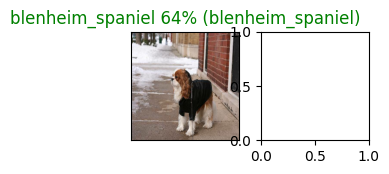

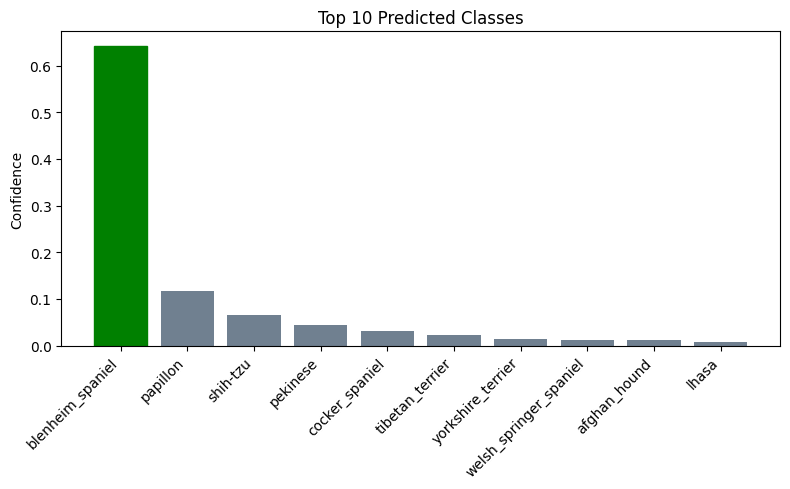

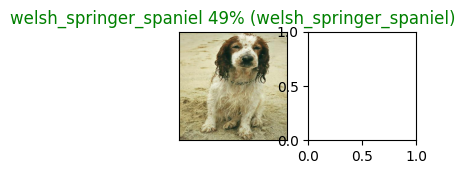

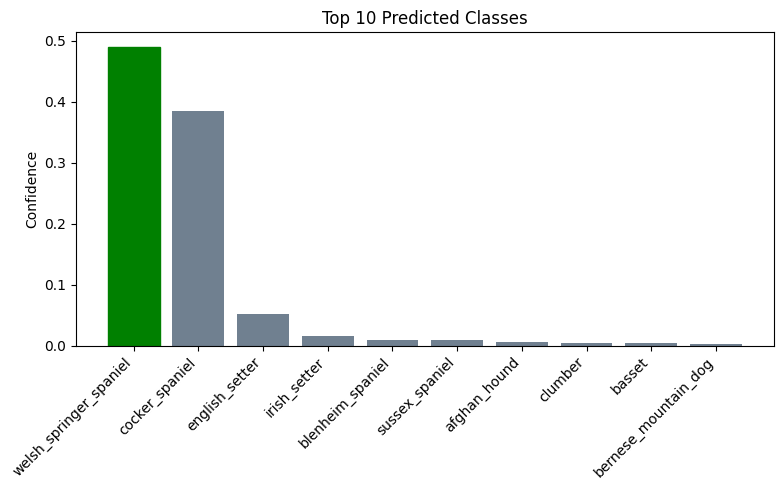

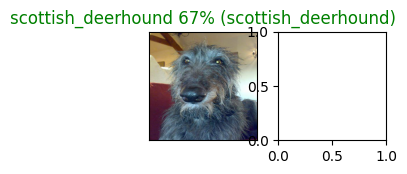

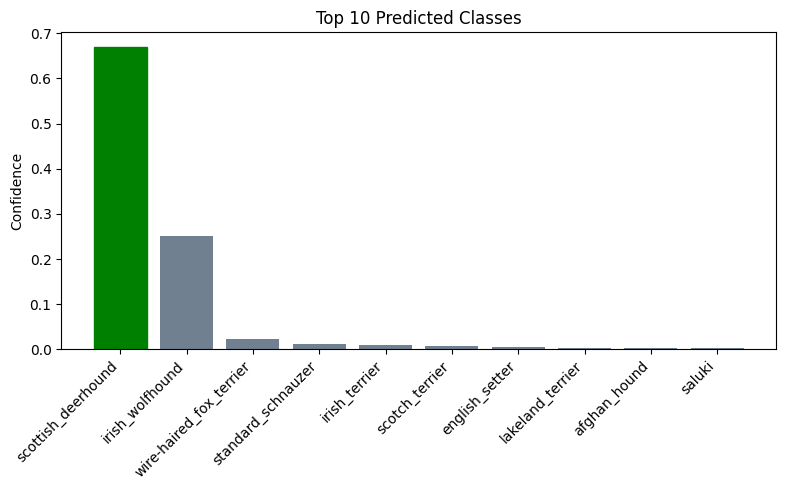

<Figure size 640x480 with 0 Axes>

In [44]:
i_multiplier = 20
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(5*2*num_cols, 5*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_pred(prediction_probabilities=predictions,
              labels=val_labels,
              images=val_images,
              n=i+i_multiplier)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_pred_conf(prediction_probabilities=predictions,
                   labels=val_labels,
                   n=i+i_multiplier)
plt.tight_layout(h_pad=1.0)
plt.show()

In [45]:
#Apply on whole dataset
full_data = create_data_batches(X, y)

In [46]:
full_model = create_model()
full_model_early_stopping = tf.keras.callbacks.EarlyStopping(monitor='accuracy',
                                                             patience=3)


Building model...


In [47]:
full_model.fit(x=full_data,
               epochs=100,
               callbacks=[full_model_early_stopping])

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 59s 159ms/step - accuracy: 0.4266 - loss: 2.6069
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.8464 - loss: 0.5617
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - accuracy: 0.9085 - loss: 0.3633
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.9454 - loss: 0.2504
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.9708 - loss: 0.1786
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.9854 - loss: 0.1317
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.9919 - loss: 0.0999
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9955 - loss: 0.0776
Epoch 9/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.9969 - loss: 0.0617
Epoch 10/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9980 - loss: 0.0500
Epoch 11/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.9983 - loss: 0.0411
Epoch 12

In [48]:
full_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,719,146 (10.37 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 307,442 (1.17 MB)

In [49]:
import datetime
#Saving model
def save_model(model, suffix=None):     # suffix to know whether model is trained on partial or full amount of data
    # create model directory with current time
    modeldir = os.path.join('/content/drive/MyDrive/Colab Notebooks/DogBreed',
                            datetime.datetime.now().strftime('%Y%m%d-%H%M%s'))
    model_path = modeldir + '-' + suffix + '.keras'
    print(f"Saving model to: {model_path}...")
    model.save(model_path)
    return model_path

save_model(full_model, suffix='full-model')

Saving model to: /content/drive/MyDrive/Colab Notebooks/DogBreed/20250827-04461756269964-full-model.keras...


'/content/drive/MyDrive/Colab Notebooks/DogBreed/20250827-04461756269964-full-model.keras'

In [51]:
#To Load model so neednt rerun again
def load_model(model_path):
    """
    loads a saved model from a specified path.
    """
    print(f'loading saved model from: {model_path}...')
    model = tf.keras.models.load_model(model_path)
    return model

loaded_full_model = load_model('/content/drive/MyDrive/Colab Notebooks/DogBreed/20250827-04461756269964-full-model.keras')


loading saved model from: /content/drive/MyDrive/Colab Notebooks/DogBreed/20250827-04461756269964-full-model.keras...


In [52]:
test_path = '/content/drive/MyDrive/Colab Notebooks/DogBreed/test'
test_filenames = [test_path + '/' + fname for fname in os.listdir(test_path)]
print(len(test_filenames))
test_filenames[:10]

10357


['/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e751e319cfdc9912ae2e5da2a9b053e0.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e7f95aabf775a636b3893ffa120adaf9.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/de5496c6b58f66ab890ab24087d9e220.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/ddf48fc0d3f0719c40332708c331a9ab.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e36ec4ab8218060660ec82fd6c4757a7.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e6926a5046cd957245918c33985bcd62.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e06fdea86b416e992137ad52bb5da5a8.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e16c4485a37ac90e1623e2da77513648.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e5942b2259c795541cd9ea68fb106406.jpg',
 '/content/drive/MyDrive/Colab Notebooks/DogBreed/test/e50319e7efc447bb684fbfdbed3ff041.jpg']

In [53]:
# create test data batch
test_data = create_data_batches(test_filenames, test_data=True)
test_predictions = full_model.predict(test_data,verbose=1)

creating TEST data batches
324/324 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step


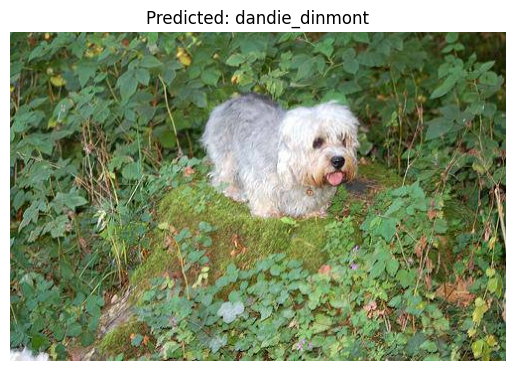

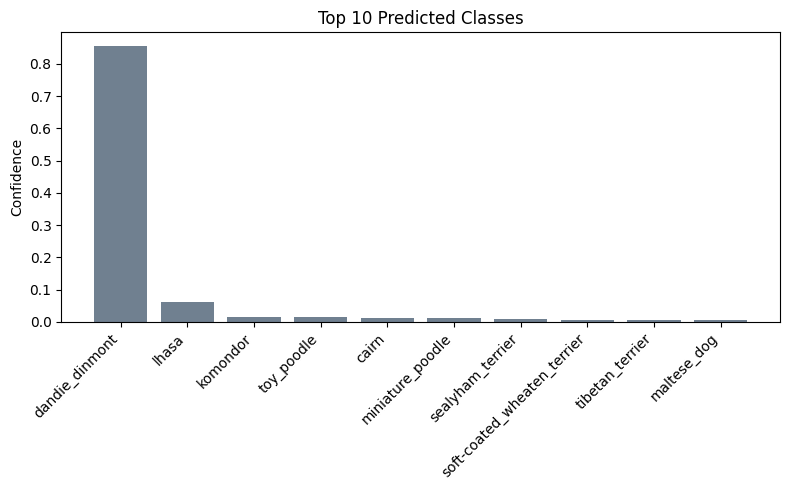

In [54]:
import matplotlib.image as mpimg
first_image_path = test_filenames[3]

img = mpimg.imread(first_image_path)
#prediction
pred = test_predictions[3]
predicted_label = get_pred_label(pred)
#Display
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_label}")
plot_pred_conf(test_predictions,3)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


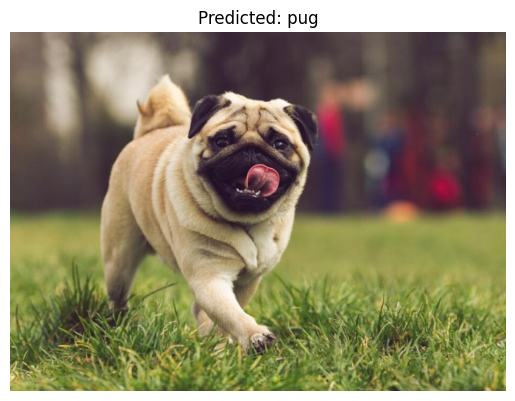

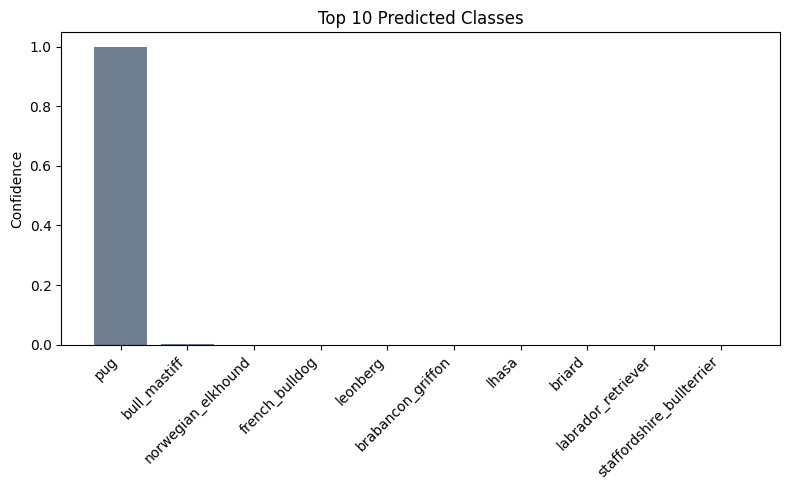

In [55]:
#Predicting on your own image
from tensorflow.keras.preprocessing import image
import numpy as np

# 1. Load your image
own_img_path = "/content/drive/MyDrive/Colab Notebooks/DogBreed/dg3.jpeg"
img = image.load_img(own_img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 224, 224, 3)

# 2. Predict
own_pred = loaded_full_model.predict(img_array)
predicted_label = get_pred_label(own_pred[0])
# 3. Display original image (in full quality, not resized)
img_display = mpimg.imread(own_img_path)
plt.imshow(img_display)
plt.axis('off')
plt.title(f"Predicted: {predicted_label}")

# 4. Plot confidence bar chart
plot_pred_conf(own_pred, 0)

plt.show()
